# Linear Regression

In Lesson 01, we learned how to frame a problem and define our Feature Matrix ($X$) and Target Vector ($y$). In Lesson 02, we learned how Gradient Descent serves as the engine to minimize error. Now, we will combine these concepts to build our very first Machine Learning algorithm: **Linear Regression**.

Linear Regression is the foundation of predictive modeling. While it may seem simple compared to deep neural networks, it is mathematically elegant, highly interpretable, and heavily relied upon in enterprise forecasting, finance, and economics.

Linear Regression is used when our Target Vector ($y$) is **continuous** (e.g., predicting revenue in dollars, temperature in degrees, or expected days until hardware failure). The algorithm assumes that a linear relationship exists between the input features and the target output.

Let's set up our Python environment to visualize the geometry and calculus of this algorithm.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Regression Modeling Environment Ready.")

✅ Regression Modeling Environment Ready.


# 1. The Mathematics of Linear Regression

Every supervised algorithm requires three mathematical components: a Hypothesis, a Cost Function, and an Optimization strategy.

### 1. The Hypothesis Function ($h_\theta$)
We hypothesize that the target $y$ can be predicted by drawing a straight line (or a hyperplane in higher dimensions) through our data. For a dataset with a single feature ($x_1$), the hypothesis is the classic algebra equation for a line:
$$h_\theta(x) = \theta_0 + \theta_1 x_1$$
*   $\theta_0$ is the **Y-Intercept** (the base prediction when $x_1 = 0$).
*   $\theta_1$ is the **Weight** or **Slope** (how much the prediction changes for a 1-unit change in $x_1$).

In professional ML, we use linear algebra to represent this for any number of features:
$$h_\theta(x) = \theta^T x$$

### 2. The Cost Function (Ordinary Least Squares)
How do we mathematically measure if our line is "good"? We use **Mean Squared Error (MSE)**. We calculate the difference between our prediction and the actual truth (the **Residual**), square it to penalize massive errors, and average it across the dataset.
$$J(\theta) = \frac{1}{2n} \sum_{i=1}^{n} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$
*The goal of the algorithm is to find the exact $\theta$ parameters that make $J(\theta)$ as small as possible.*

# 2. Visualizing the Residuals

Let's simulate a corporate dataset: predicting **Q4 Sales Revenue** ($y$) based on **Q3 Marketing Spend** ($X$). We will fit a linear model and physically draw the Cost Function (the residuals) on the screen.

Learned Equation: Revenue = $61.68K + $2.19K * (Marketing Spend)


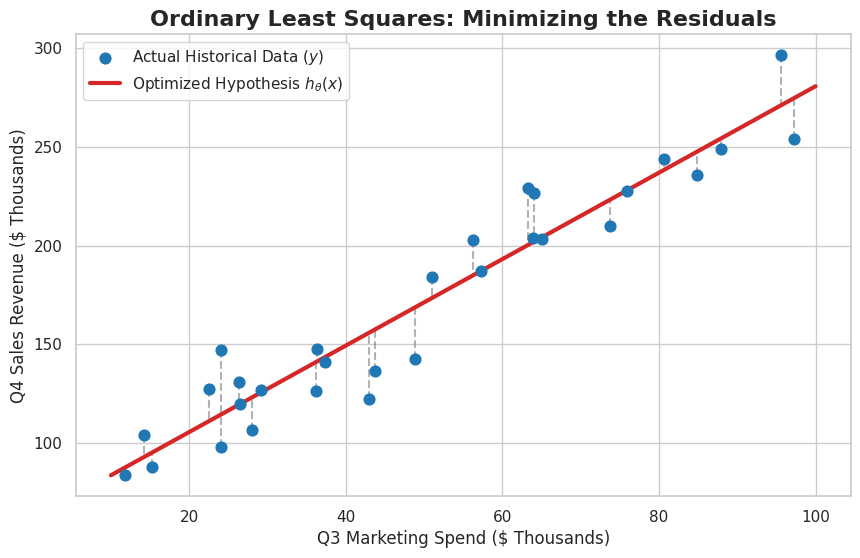

In [2]:
# 1. Simulate corporate data
np.random.seed(42)
marketing_spend = np.random.uniform(10, 100, 30) # X (in thousands)
# True relationship: Revenue = 50 + 2.5 * Spend + Random Noise
revenue = 50 + (2.5 * marketing_spend) + np.random.normal(0, 20, 30) # y (in thousands)

X = marketing_spend.reshape(-1, 1)

# 2. Train (Fit) the Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X, revenue)

# 3. Extract the learned parameters
theta_0 = lin_reg.intercept_
theta_1 = lin_reg.coef_[0]
print(f"Learned Equation: Revenue = ${theta_0:.2f}K + ${theta_1:.2f}K * (Marketing Spend)")

# 4. Matplotlib Visualization of the Math
plt.figure(figsize=(10, 6))

# Plot raw data
plt.scatter(marketing_spend, revenue, color='#1f77b4', s=60, label='Actual Historical Data ($y$)', zorder=3)

# Plot the Hypothesis Line
x_range = np.array([10, 100]).reshape(-1, 1)
y_pred_line = lin_reg.predict(x_range)
plt.plot(x_range, y_pred_line, color='#d62728', linewidth=3, label=r'Optimized Hypothesis $h_\theta(x)$', zorder=2)

# Plot the Residuals (The physical representation of the Error)
predictions = lin_reg.predict(X)
for i in range(len(marketing_spend)):
    plt.plot([marketing_spend[i], marketing_spend[i]], 
             [revenue[i], predictions[i]], 
             color='gray', linestyle='--', alpha=0.6, zorder=1)

plt.title("Ordinary Least Squares: Minimizing the Residuals", fontsize=16, fontweight='bold')
plt.xlabel("Q3 Marketing Spend ($ Thousands)")
plt.ylabel("Q4 Sales Revenue ($ Thousands)")
plt.legend()
plt.show()

*(Insight: Look at the gray dashed lines in the plot. These are the residuals. The red line was placed in the exact mathematical position that ensures the sum of the squares of those gray lines is as tiny as mathematically possible.)*

# 3. Two Paths to Optimization (Closed-Form vs. Gradient Descent)

How did `LinearRegression()` find that perfect red line? There are actually two completely different mathematical ways to solve this problem.

### Method A: The Normal Equation (Closed-Form)
Because the MSE cost function is a perfect convex parabola, we don't actually need Gradient Descent to slowly walk down the hill. We can use advanced calculus, take the derivative of the cost function, set it exactly to zero, and solve for $\theta$ instantly using Linear Algebra:
$$\theta = (X^T X)^{-1} X^T y$$
*   **Pros**: Finds the exact, perfect answer in one step. No learning rate ($\alpha$) to tune.
*   **Cons**: Inverting the matrix $(X^T X)$ is computationally brutal. If your dataset has 100,000 features, this math will crash your server's memory. Scikit-learn's standard `LinearRegression()` uses a variation of this method.

### Method B: Stochastic Gradient Descent (Iterative)
If your dataset is massive (millions of rows), you cannot use the Normal Equation. Instead, you must use the Gradient Descent engine we learned in Lesson 02. Scikit-learn provides `SGDRegressor()` for this exact enterprise scenario.

In [3]:
# Train using Gradient Descent instead of the Normal Equation
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.01, random_state=42)

# We MUST scale our data before using Gradient Descent, otherwise it might explode (diverge)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sgd_reg.fit(X_scaled, revenue)

print("--- Gradient Descent Optimization ---")
print("SGD successfully converged to the same optimal parameters iteratively!")

--- Gradient Descent Optimization ---
SGD successfully converged to the same optimal parameters iteratively!


# 4. Evaluating the Model ($R^2$ Score)

Once we draw the line, we need to know how well it explains the real world. In regression, the standard metric is the **$R^2$ Score (Coefficient of Determination)**. 

$R^2$ measures the percentage of variance in the Target ($y$) that can be explained by our Features ($X$).
*   $R^2 = 1.0$: The model perfectly predicts every data point.
*   $R^2 = 0.0$: The model is no better than the naive statistical baseline (just guessing the average).

In [4]:
# Calculate R-Squared
r2 = r2_score(revenue, predictions)
print(f"🚨 Model R^2 Score: {r2:.3f}")
print(f"Insight: Our marketing spend explains {r2*100:.1f}% of the variance in Q4 Revenue.")

🚨 Model R^2 Score: 0.918
Insight: Our marketing spend explains 91.8% of the variance in Q4 Revenue.


## Real-World Use Case or Analogy:
Think of Linear Regression like **Tuning a Sound Mixing Board**:

*   **The Features ($X$)**: You have sliders for Bass, Treble, and Reverb. 
*   **The Target ($y$)**: The overall acoustic quality of the music track.
*   **The Hypothesis**: You assume that turning up the Treble slider a specific amount ($\theta_1$) will linearly increase the acoustic quality.
*   **The Residuals**: The sound engineer listens to the output and compares it to the perfect studio recording. Every squeak or muffled note is a residual (an error).
*   **The Optimization**: The engineer slowly adjusts the sliders (Gradient Descent) or calculates the exact perfect frequencies in a software program (Normal Equation) until the track matches the studio recording as closely as physically possible.

---